# FREIGHT ANALYSIS

## BUSINESS CASE

1. Kategori produk mana yang memiliki rata-rata freight value tertinggi?
2. Apakah freight value yang tinggi berpengaruh terhadap review score?
3. Customer State mana yang menanggung freight value tertinggi rata-rata per order?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
customer = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/customers_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
order_review = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_reviews_dataset.csv')
name_translate_product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/product_category_name_translation.csv')
product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/products_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
customer.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
order_review.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_review : 1 row merepresntasikan 1 review dalam sebuah order
3. tabel order_items : 1 row mempresentasikan item dalam sebuah order
4. tabel customer : 1 row mempresentasikan 1 pelanggan atau customer
5. tabel products : 1 row mempresentasikan 1 product

### KEY COLUMN 

1. **Tabel `order_review`**:
   - `order_id` → identifier untuk setiap order, digunakan untuk menghubungkan `order` dan `order_review`
   - `review_score` → score review untuk tiap order
     

2.  **Tabel `order`**:
    - `order_id` → identifier untuk setiap order
    - `customer_id` → identifier customer digunakan untuk menghubungkan `order` dengan `customer`
      
      
3. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan `order_items` dengan `orders`
   - `order_item_id` → identifier order item id
   - `freight_value` → nilai freight/pengiriman
   - `product_id` → identifier product, digunakan untuk menghubungkan `order_items` dengan `products`


4. **Tabel `customer`**:
   - `customer_id` → identifier untuk setiap customer
   - `customer_unique_id` → ID yang merepresentasikan customer yang sebenarnya/unik
   - `customer_state` → state tiap customer

5. **Tabel `products`**:
   - `product_id` → identifier untuk setiap product
   - `product_category_name` → kategori product

### RELATIONSHIP TABLE

- Tabel `order_review` dan `order` terhubung melalui `order_id`.
- Tabel `order` dan `order_items` terhubung melalui `order_id`.
- Tabel `order` dan `customer` terhubung melalui `customer_id`.
- Tabel `order_items` dan `products` terhubung melalui `product_id`.

- `order_review` memiliki hubungan **one-to-one (1:1)** dengan `order`, karena satu order memiliki satu order_review .    
- `order` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.
- `order` memiliki hubungan **many-to-one (N:1)** dengan `customer`, karena satu customer dapat memiliki beberapa order.
- `products` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu product dapat muncul pada beberapa order item.

## DATA QUALITY

In [7]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [8]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [9]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [10]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

In [11]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [12]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [13]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [14]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [15]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [16]:
customer.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [17]:
print('Checking null value')
customer.isna().sum()

Checking null value


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [18]:
print('Checking duplicated value')
customer.duplicated().sum()

Checking duplicated value


0

In [19]:
print('Checking duplicated value')
customer.duplicated().sum()

Checking duplicated value


0

In [20]:
order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [21]:
order_review.describe(include='all')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


In [22]:
print('Checking null value')
order_review.isna().sum()

Checking null value


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

1.  Untuk kolom ```review_comment_message```, ```review_comment_title``` terdapat missing value

In [23]:
print('Checking duplicated value')
order_review.duplicated().sum()

Checking duplicated value


0

In [24]:
print('Checking duplicated value')
order_review.duplicated().sum()

Checking duplicated value


0

In [25]:
print('Checking duplicated value order_id')
order_review['order_id'].duplicated().sum()

Checking duplicated value order_id


551

Pada tabel order_reviews ditemukan beberapa order_id yang memiliki lebih dari satu review record. Kondisi ini perlu diperhatikan karena order_id tidak selalu merepresentasikan satu review record.

In [26]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [27]:
product.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [28]:
print('Checking null value')
product.isna().sum()

Checking null value


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

1.  Untuk kolom ```product_category_name```,```product_name_lenght```,```product_description_lenght```,``` product_photos_qty```,```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'``` terdapat missing value

In [29]:
print('Checking duplicated value')
product.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

#### MENGUBAH DI TABEL PRODUCT NAMA PRODUCT YANG NULL MENJADI UNKOWN + 5 HURUF TERAKHIR PRODUCT ID 

In [30]:
product['product_category_name'] = product['product_category_name'].fillna(
    'unkown_' + product['product_id'].str[-5:])

**DATA QUALITY NOTE**

Pada kolom `product_category_name` ditemukan nilai null. Karena produk dengan kategori yang tidak tersedia tetap memiliki `product_id` dan masih relevan untuk analisis, data tersebut tidak dikeluarkan. Nilai null kemudian ditangani dengan membuat label **`unkown_` + 5 karakter terakhir dari `product_id`** sebagai identifikasi kategori yang tidak diketahui.


#### MENGISI KOLOM NAME LENGTH, DESCRIPTION LENGHT, DAN PHOTOS QTY DENGAN 0

In [31]:
product['product_name_lenght'] = product['product_name_lenght'].fillna(0)
product['product_description_lenght'] = product['product_description_lenght'].fillna(0)
product['product_photos_qty'] = product['product_photos_qty'].fillna(0)

In [32]:
print('Jumlah missing value setelah dilakukan penanganan')
product.isna().sum()

Jumlah missing value setelah dilakukan penanganan


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

**DATA QUALITY NOTE**

Pada pemeriksaan data ditemukan **2 missing value pada `product_weight_g`**. Karena variabel tersebut digunakan dalam analisis EDA Q2 untuk melihat hubungan antara berat produk dan `freight_value`, treatment terhadap missing value akan dilakukan pada saat proses pengerjaan agar penanganan data disesuaikan dengan kebutuhan analisis.


#### TRANSLATE PRODUCT CATEGORY NAME

In [33]:
translate = name_translate_product.set_index('product_category_name')['product_category_name_english']
product['product_category_name'] = product['product_category_name'].map(translate).fillna(product['product_category_name'])

## DATA PREPARATION 

### DATA PREP Q1

#### MENGAMBIL FITUR YANG PENTING UNTUK EDA Q1

In [34]:
product_q1 = product[['product_id','product_category_name']]
order_items_q1 = order_items[['order_id','order_item_id','freight_value','product_id']]

#### JOIN TABEL UNTUK EDA Q1

In [35]:
data_q1 = pd.merge(
    left = order_items_q1,
    right = product_q1,
    how = 'left',
    on = 'product_id'
)
data_q1

,order_id,order_item_id,freight_value,product_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,13.29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,19.93,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,17.87,c777355d18b72b67abbeef9df44fd0fd,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,12.79,7634da152a4610f1595efa32f14722fc,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,18.14,ac6c3623068f30de03045865e4e10089,garden_tools
...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,43.41,4aa6014eceb682077f9dc4bffebc05b0,housewares
112646,fffcd46ef2263f404302a634eb57f7eb,1,36.53,32e07fd915822b0765e448c4dd74c828,computers_accessories
112647,fffce4705a9662cd70adb13d4a31832d,1,16.95,72a30483855e2eafc67aee5dc2560482,sports_leisure
112648,fffe18544ffabc95dfada21779c9644f,1,8.72,9c422a519119dcad7575db5af1ba540e,computers_accessories


In [36]:
data_q1.isna().sum()

order_id                 0
order_item_id            0
freight_value            0
product_id               0
product_category_name    0
dtype: int64

### DATA PREP Q2

#### MENGAMBIL FITUR YANG PENTING UNTUK EDA Q2

In [37]:
order_items_q2 =  order_items[['order_id', 'freight_value' ]]
order_review_q2 = order_review[['order_id', 'review_score']]

#### MELAKUKAN AGREGASI PADA FREIGHT VALUE DAN REVIEW SCORE

In [38]:
## MELAKUKAN AGREGASI SUM TIAP FREIGHT VALUE PER ORDEER_ID
order_items_q2 = order_items_q2.groupby('order_id')['freight_value'].sum().reset_index()

In [39]:
## MELAKUKAN AGREGASI MEAN TIAP REVIEW SCROE PER ORDEER_ID
order_review_q2 = order_review_q2.groupby('order_id')['review_score'].mean().reset_index()

#### JOIN TABEL

In [40]:
data_q2 = pd.merge(
    left = order_items_q2,
    right = order_review_q2,
    how = 'inner',
    on = 'order_id'
)
data_q2.isna().sum()

order_id         0
freight_value    0
review_score     0
dtype: int64

### DATA PREP Q3

#### MENGAMBIL FITUR YANG PENTING UNTUK EDA Q3

In [41]:
customer_q3 = customer[['customer_id','customer_state']]
order_q3 = order[['order_id','customer_id']]
order_items_q3 = order_items[['order_id','freight_value']]

#### MELAKUKAN AGREGASI PADA FREIGHT VALUE

In [42]:
## MELAKUKAN AGREGASI SUM TIAP FREIGHT VALUE PER ORDEER_ID
order_items_q3 = order_items_q3.groupby('order_id')['freight_value'].sum().reset_index()

#### JOIN TABEL

In [43]:
customer_order = pd.merge(
    left = order_q3,
    right = customer_q3,
    how = 'left',
    on = 'customer_id'
)

In [44]:
customer_order.isna().sum()

order_id          0
customer_id       0
customer_state    0
dtype: int64

In [45]:
data_q3 = pd.merge(
    left = customer_order,
    right = order_items_q3,
    how = 'inner',
    on = 'order_id'
)

In [46]:
data_q3.isna().sum()

order_id          0
customer_id       0
customer_state    0
freight_value     0
dtype: int64

## EXPLORATORY DATA ANALYSIS

### 1. Kategori produk mana yang memiliki rata-rata freight value tertinggi?

In [47]:
data_q1

,order_id,order_item_id,freight_value,product_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,13.29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,19.93,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,17.87,c777355d18b72b67abbeef9df44fd0fd,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,12.79,7634da152a4610f1595efa32f14722fc,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,18.14,ac6c3623068f30de03045865e4e10089,garden_tools
...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,43.41,4aa6014eceb682077f9dc4bffebc05b0,housewares
112646,fffcd46ef2263f404302a634eb57f7eb,1,36.53,32e07fd915822b0765e448c4dd74c828,computers_accessories
112647,fffce4705a9662cd70adb13d4a31832d,1,16.95,72a30483855e2eafc67aee5dc2560482,sports_leisure
112648,fffe18544ffabc95dfada21779c9644f,1,8.72,9c422a519119dcad7575db5af1ba540e,computers_accessories


In [48]:
data_q1_clean = data_q1.groupby('product_category_name')['freight_value'].mean().reset_index()
data_q1_clean.sort_values(by='freight_value', ascending=False).head(20)

,product_category_name,freight_value
656,unkown_f6812,162.080
437,unkown_9b473,135.340
460,unkown_a303b,133.730
365,unkown_7c834,131.010
648,unkown_f2f33,110.260
328,unkown_6cb36,98.130
135,unkown_1a8e6,98.020
245,unkown_4594f,87.465
267,unkown_4e9f2,86.600
277,unkown_5379d,86.530


**CATATAN:** Pada kolom `product_category_name` terdapat beberapa nilai yang telah ditangani menggunakan label `unkown_` + 5 karakter terakhir dari `product_id` untuk mempertahankan data produk yang memiliki kategori tidak tersedia. Namun, label `unkown_*` tersebut bukan merupakan kategori produk sebenarnya, sehingga tidak digunakan dalam perbandingan rata-rata `freight_value` antar-kategori pada Q1. Data dengan label `unkown_*` hanya dikeluarkan khusus dari analisis Q1 dan tidak dihapus dari dataset utama maupun digunakan sebagai kategori pada analisis lainnya.


In [49]:
data_q1_clean = data_q1_clean[~data_q1_clean['product_category_name'].str.contains('unkown', na=False)]
data_q1_clean.sort_values(by='freight_value', ascending=False).head(10)

,product_category_name,freight_value
14,computers,48.454680
45,home_appliances_2,44.538571
41,furniture_mattress_and_upholstery,42.906842
51,kitchen_dining_laundry_garden_furniture,42.702598
38,furniture_bedroom,42.497523
57,office_furniture,40.551124
66,small_appliances_home_oven_and_coffee,36.156053
40,furniture_living_room,35.722008
64,signaling_and_security,32.702613
50,industry_commerce_and_business,29.420448


C:\Users\adien\AppData\Local\Temp\ipykernel_21892\2640847290.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


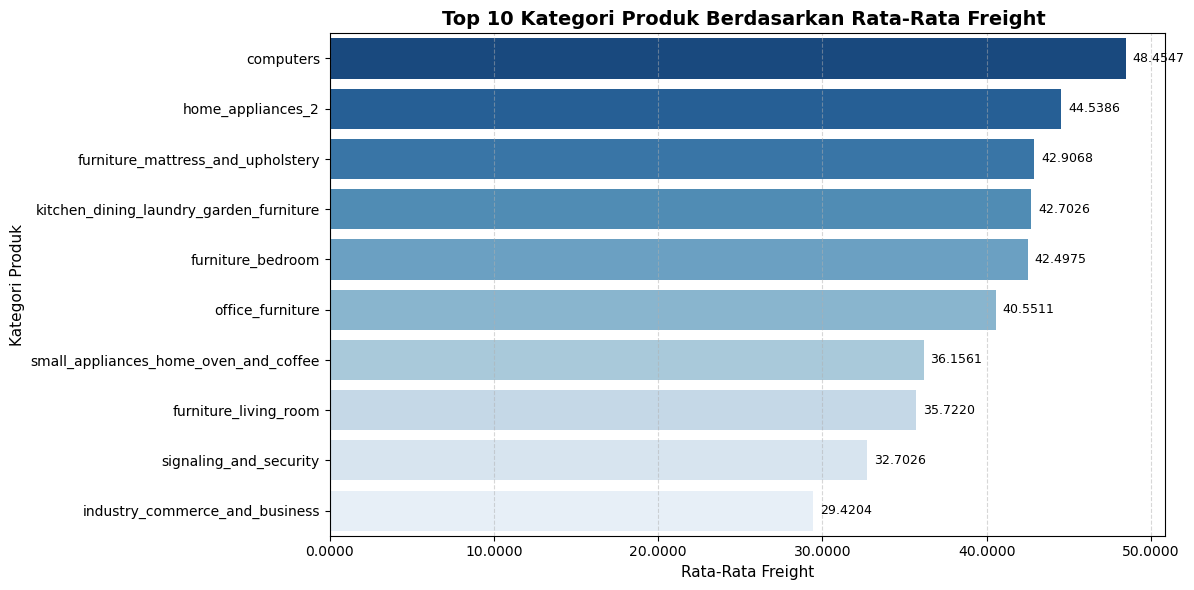

In [50]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10_freight_value = data_q1_clean.sort_values(by='freight_value', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10_freight_value,
    x='freight_value',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.4f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Rata-Rata Freight ', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Freight', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. produk dengan rata-rata freight value tertinggi yaitu computers dengan rata-rata freight value sebesar 48.454680
2. produk dengan rata-rata freight value tertinggi kedua yaitu home_appliances_2 dengan rata-rata freight value sebesar 44.538571

### 2. Apakah freight value yang tinggi berpengaruh terhadap review score?

In [51]:
data_q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97917 entries, 0 to 97916
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       97917 non-null  object 
 1   freight_value  97917 non-null  float64
 2   review_score   97917 non-null  float64
dtypes: float64(2), object(1)
memory usage: 2.2+ MB


In [52]:
data_q2_clean = data_q2[['freight_value','review_score']]
data_q2_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97917 entries, 0 to 97916
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   freight_value  97917 non-null  float64
 1   review_score   97917 non-null  float64
dtypes: float64(2)
memory usage: 1.5 MB


In [53]:
data_q2_clean.corr()

,freight_value,review_score
freight_value,1.000000,-0.088623
review_score,-0.088623,1.000000


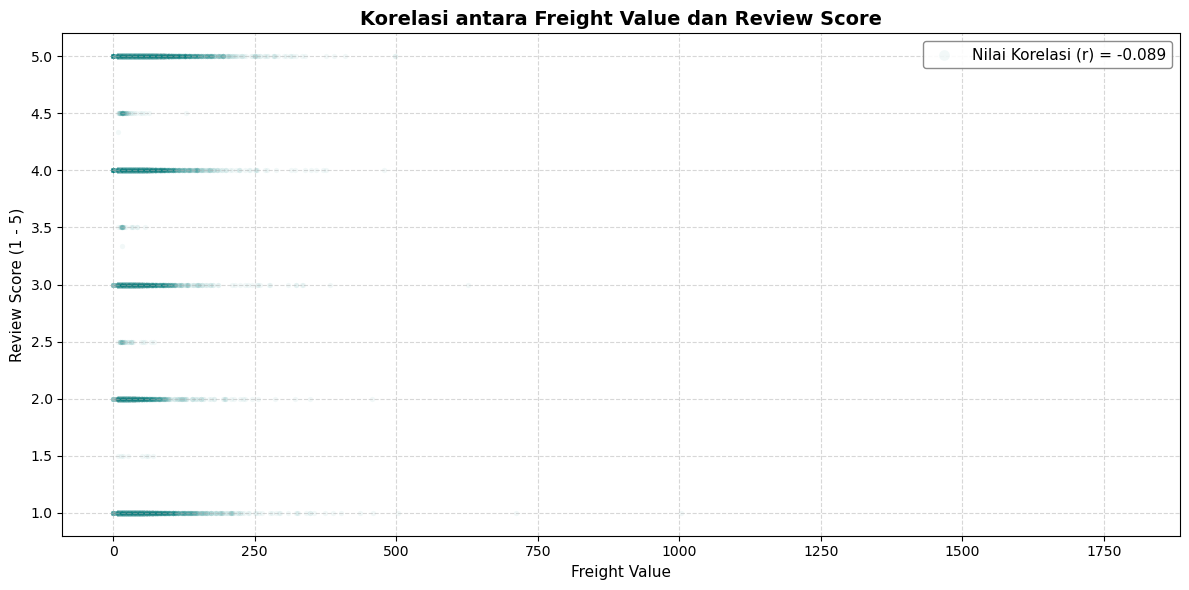

In [54]:
# 1. Menghitung nilai korelasi Pearson
korelasi = data_q2_clean['freight_value'].corr(data_q2_clean['review_score'])

plt.figure(figsize=(12, 6))

# 2. Membuat Scatter Plot
# Menggunakan parameter 'label' untuk mendeklarasikan teks yang akan muncul di legenda
sns.scatterplot(
    data=data_q2_clean,
    x='freight_value',
    y='review_score',
    alpha=0.05,        # Transparansi 5% agar tumpukan 97 ribu data terlihat gradasinya
    color='teal',
    s=15,              # Ukuran titik diperkecil
    label=f'Nilai Korelasi (r) = {korelasi:.3f}'
)

# 3. Menampilkan dan mengatur posisi Legenda
plt.legend(
    loc='upper right', 
    fontsize=11, 
    frameon=True, 
    framealpha=0.9, 
    edgecolor='gray',
    markerscale=2      # Memperbesar ukuran titik warna di dalam kotak legenda saja
)

# 4. Judul dan Label Sumbu
plt.title('Korelasi antara Freight Value dan Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value', fontsize=11)
plt.ylabel('Review Score (1 - 5)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT

Korelasi antara `freight_value` dan `review_score`, diperoleh nilai korelasi sebesar **-0,088623**. Nilai tersebut menunjukkan adanya **korelasi negatif dengan tingkat kekuatan sangat lemah** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan. Hal ini menunjukkan bahwa **freight value yang lebih tinggi cenderung berkaitan dengan `review_score` yang lebih rendah**, namun hubungan tersebut sangat lemah.


### 3. Customer State mana yang menanggung freight value tertinggi rata-rata per order?

In [55]:
data_q3_clean = data_q3.groupby('customer_state')['freight_value'].mean().reset_index()

In [56]:
data_q3_clean

,customer_state,freight_value
0,AC,45.515432
1,AL,38.721630
2,AM,37.271361
3,AP,41.007353
4,BA,29.826289
5,CE,36.436767
6,DF,23.823765
7,ES,24.575111
8,GO,26.464863
9,MA,42.599689


C:\Users\adien\AppData\Local\Temp\ipykernel_21892\2255753354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


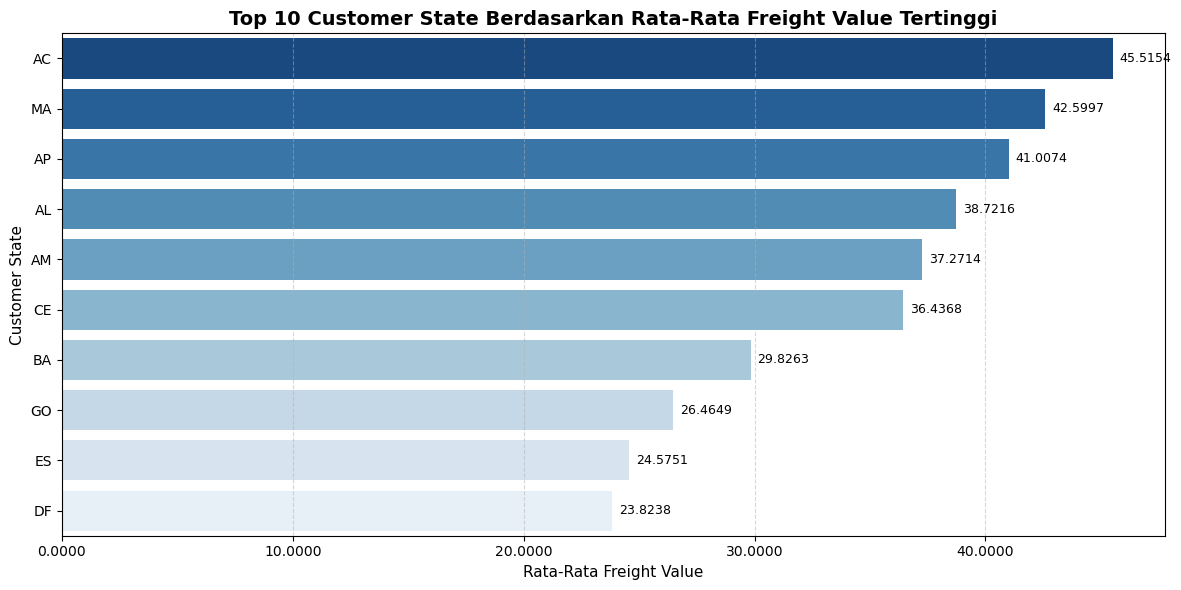

In [57]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10_state = data_q3_clean.head(10).sort_values(by='freight_value', ascending=False)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10_state,
    x='freight_value',            # Sumbu X (Angka)
    y='customer_state',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.4f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.4f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Customer State Berdasarkan Rata-Rata Freight Value Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Freight Value', fontsize=11)
plt.ylabel('Customer State', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. State AC merupakan customer state dengan rata-rata freight value tertinggi sebesar 45,5154
2. State AC merupakan customer state dengan rata-rata freight value tertinggi kedua sebesar 42,5997

## KEY FINDINGS

1. produk dengan rata-rata freight value tertinggi yaitu computers dengan rata-rata freight value sebesar 48.454680
2. produk dengan rata-rata freight value tertinggi kedua yaitu home_appliances_2 dengan rata-rata freight value sebesar 44.538571
3. Korelasi antara `freight_value` dan `review_score`, diperoleh nilai korelasi sebesar **-0,088623**. Nilai tersebut menunjukkan adanya **korelasi negatif dengan tingkat kekuatan sangat lemah** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan. Hal ini menunjukkan bahwa **freight value yang lebih tinggi cenderung berkaitan dengan `review_score` yang lebih rendah**, namun hubungan tersebut sangat lemah.
4. State AC merupakan customer state dengan rata-rata freight value tertinggi sebesar 45,5154
5. State AC merupakan customer state dengan rata-rata freight value tertinggi kedua sebesar 42,5997

## BUSINESS IMPLICATION

1. Kategori `computers` dan `home_appliances_2` memiliki rata-rata freight value tertinggi. Bisnis dapat mengevaluasi strategi pengiriman, pemilihan carrier, dan efisiensi distribusi untuk kategori dengan karakteristik pengiriman yang memiliki biaya freight relatif tinggi.

2. Terdapat korelasi negatif yang sangat lemah antara freight value dan review score. Freight value dapat dipertimbangkan sebagai salah satu indikator dalam evaluasi pengalaman pelanggan, namun perlu dikombinasikan dengan faktor lain seperti waktu pengiriman, kualitas produk, dan proses fulfillment karena hubungan yang ditemukan sangat lemah.

3. State `AC` dan state dengan rata-rata freight value tinggi lainnya dapat menjadi area yang perlu mendapatkan perhatian lebih dalam evaluasi biaya pengiriman. Analisis lanjutan dapat digunakan untuk melihat apakah tingginya freight berkaitan dengan jarak geografis, karakteristik produk, atau kondisi operasional pada wilayah tersebut.

4. Kombinasi antara kategori produk dan customer state dapat digunakan sebagai dasar untuk mengidentifikasi pola biaya freight yang tinggi. Informasi ini dapat membantu bisnis menentukan prioritas evaluasi terhadap rute, carrier, dan strategi distribusi.
